In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [2]:
import os
os.chdir(r"G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting")
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [3]:
df = pd.read_csv(r'airline_passengers.csv', index_col ='Month', parse_dates = True)

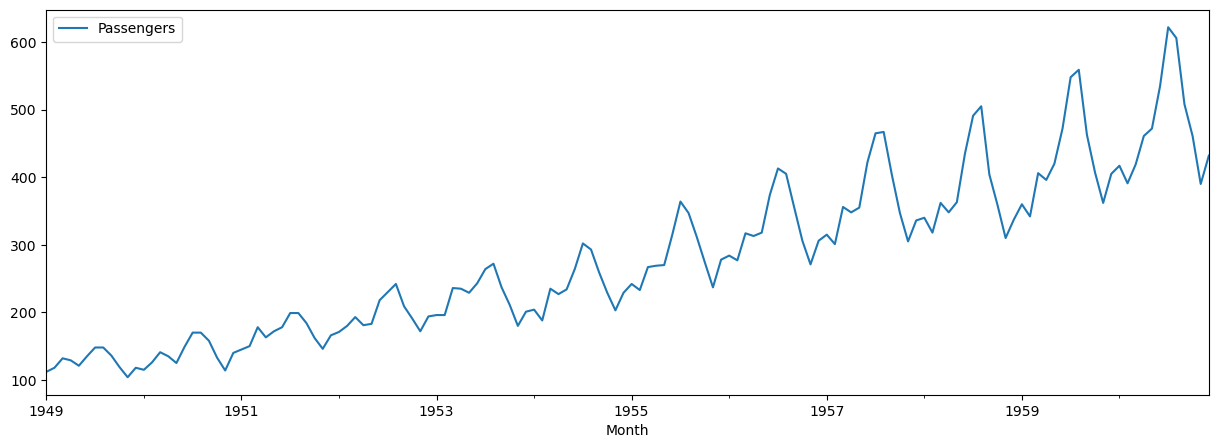

In [6]:
df.plot(figsize = (15,5));

In [8]:
adfuller(df['Passengers'])

(np.float64(0.8153688792060597),
 np.float64(0.9918802434376411),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [10]:
'''check the documentation
- null hypothesis - data is non stationary
- alternate hypothesis - data is stationary
    - the 1st value is called test statistic, 2nd value is the p value, and 1%,5% and 10% are called critical values
        - understanding results
            - if test statistic is more negative than 1% critical value, then reject the null hypothesis with 99% confidence
            - if test statistic is more negative then 5% critical value, then reject the null hypothesis with 95% confidence 
            - the critical values are almost always -ve, so if test statistic is +ve, then we cant reject the null hypothesis and data is definitely non-stationary
    - why use p-value?
            - this is actually looked at first
            - acts as a shortcut 
            - instead of manually comparing test statistics against different critical values -1%,5%,10%, p-value summarizes all that into single number
                    - if p-value < 0.05, we have passed the 5% critical value threshold 
                    - if p-value < 0.01, we have passed the 1% critical value threshold
            - p-value tells if it is stationary or not, but doesnt tell how far test statistic is compared to critical values'''

'check the documentation\n- null hypothesis - data is non stationary\n- alternate hypothesis - data is stationary\n    - the 1st value is called test statistic, 2nd value is the p value, and 1%,5% and 10% are called critical values\n        - understanding results\n            - if test statistic is more negative than 1% critical value, then reject the null hypothesis with 99% confidence\n            - if test statistic is more negative then 5% critical value, then reject the null hypothesis with 95% confidence \n            - the critical values are almost always -ve, so if test statistic is +ve, then we cant reject the null hypothesis and data is definitely non-stationary\n    - why use p-value?\n            - this is actually looked at first\n            - acts as a shortcut \n            - instead of manually comparing test statistics against different critical values -1%,5%,10%, p-value summarizes all that into single number\n                    - if p-value < 0.05, we have passed

In [12]:
def adf(x):
    res = adfuller(x)
    print("Test-Statistics:", res[0])
    print("p-value:", res[1])

    if res[1] < 0.05:
        print("stationary")
    else:
        print("Non-Stationary")

In [13]:
adf(df['Passengers'])

Test-Statistics: 0.8153688792060597
p-value: 0.9918802434376411
Non-Stationary


In [14]:
adf(np.random.randn(100))

Test-Statistics: -8.927697602976895
p-value: 1.0008903839158565e-14
stationary


In [19]:
adf(np.random.gamma(1,1,100))

Test-Statistics: -8.063969950369666
p-value: 1.614811456380653e-12
stationary


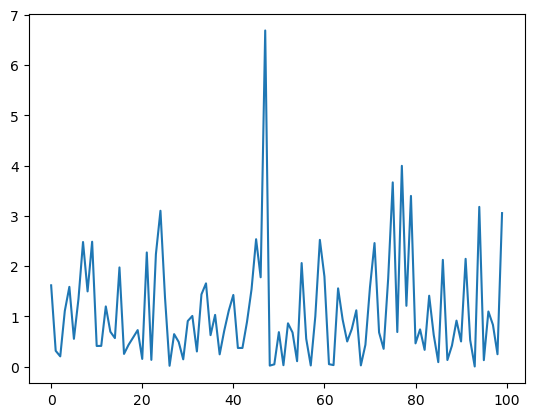

In [18]:
plt.plot(np.random.gamma(1,1,100));

In [20]:
df['LogPassengers'] = np.log(df['Passengers'])

In [21]:
adf(df['LogPassengers'])

Test-Statistics: -1.7170170891069636
p-value: 0.4223667747703897
Non-Stationary


<Axes: xlabel='Month'>

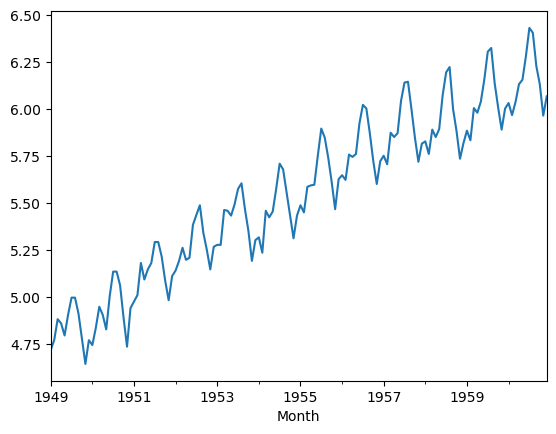

In [22]:
''' clearly able to see that this is non stationary'''
df['LogPassengers'].plot()

In [23]:
df['Diff'] = df['Passengers'].diff()

In [52]:
''' the above operation takes diff between previous value and the next value'''

' the above operation takes diff between previous value and the next value'

<Axes: xlabel='Month'>

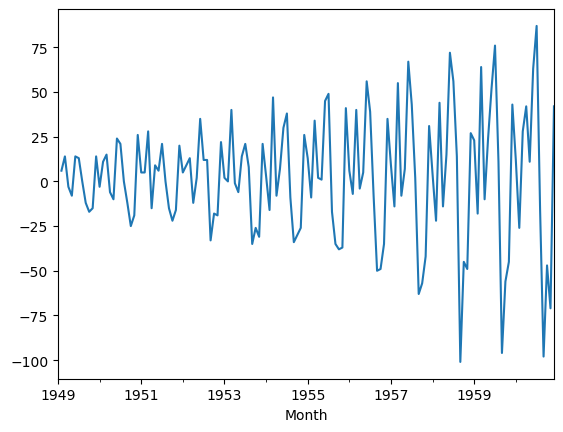

In [25]:
'''clearly shows that the variance is increasing with time so non stationary'''
df['Diff'].plot()

In [29]:
adf(df['Diff'].dropna()) # doing drop na since 1st value was nan

Test-Statistics: -2.829266824169992
p-value: 0.0542132902838265
Non-Stationary


In [38]:
''' although variance seemed to increase with time looking at the plot, the p value is surprisingly close to 0.05'''

' although variance seemed to increase with time looking at the plot, the p value is surprisingly close to 0.05'

In [40]:
adfuller(df['Diff'].dropna())

(np.float64(-2.829266824169992),
 np.float64(0.0542132902838265),
 12,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(988.5069317854085))

In [42]:
''' the above shows that test statistic is less than 10% critical value but just more than 5% critical value.
thus, with say 90% (94.5% to be precise looking at p-value) confidence, we can say that the data is stationary'''

' the above shows that test statistic is less than 10% critical value but just more than 5% critical value.\nthus, with say 90% (94.5% to be precise looking at p-value) confidence, we can say that the data is stationary'

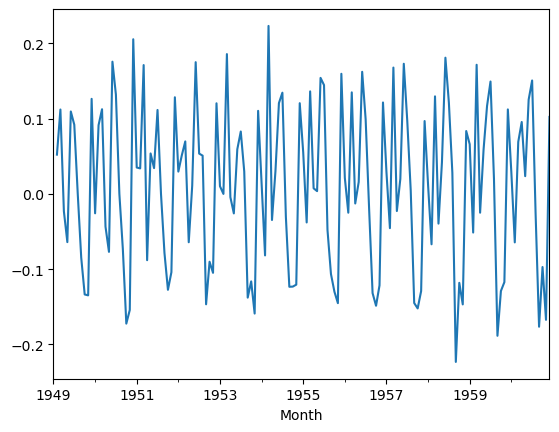

In [30]:
df['DiffLog'] = df['LogPassengers'].diff()
df['DiffLog'].plot();

In [31]:
'''the above looks stationary since mean and variance appear to be stationary with time'''

'the above looks stationary since mean and variance appear to be stationary with time'

In [33]:
adf(df['DiffLog'].dropna())

Test-Statistics: -2.7171305983881675
p-value: 0.07112054815085295
Non-Stationary


In [41]:
''' compared to the Non Log diff, surprisingly, the p value is higher here. this is very surprising'''

' compared to the Non Log diff, surprisingly, the p value is higher here. this is very surprising'

In [35]:
adfuller(df['DiffLog'].dropna())

(np.float64(-2.7171305983881675),
 np.float64(0.07112054815085295),
 14,
 128,
 {'1%': np.float64(-3.4825006939887997),
  '5%': np.float64(-2.884397984161377),
  '10%': np.float64(-2.578960197753906)},
 np.float64(-440.35846985568105))

In [37]:
''' the above shows that test statistic is less than 10% critical value but more than 5% critical value.
thus, with say 90% (93% to be precise looking at p-value) confidence, we can say that the data is stationary'''

' the above shows that test statistic is less than 10% critical value but more than 5% critical value.\nthus, with say 90% (93% to be precise looking at p-value) confidence, we can say that the data is stationary'

## stock price analysis

In [44]:
stocks = pd.read_csv('sp500sub.csv', index_col = 'Date', parse_dates = True)

In [46]:
stocks.head()

,Open,High,Low,Close,Adj Close,Volume,Name
Date,,,,,,,
2010-01-04,9.22,9.51,9.17,9.50,9.50,1865400.0,INCY
2010-01-05,9.51,10.29,9.45,10.27,10.27,7608900.0,INCY
2010-01-06,10.38,11.09,10.35,11.00,11.00,8046700.0,INCY
2010-01-07,11.00,11.06,10.62,10.82,10.82,3680300.0,INCY
2010-01-08,10.82,11.00,10.75,10.94,10.94,1529300.0,INCY


In [48]:
goog = stocks[stocks['Name']=='GOOG'][['Close']]

In [49]:
goog['LogPrice']=np.log(goog['Close'])

In [55]:
goog['LogRet'] = goog['LogPrice'].diff()
## taking diff between current log price and previous log price

<Axes: xlabel='Date'>

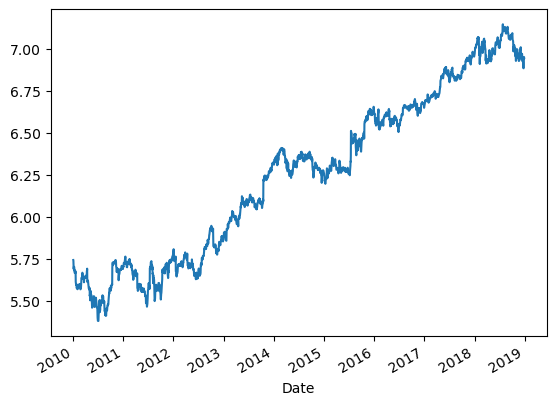

In [56]:
goog['LogPrice'].plot()

<Axes: xlabel='Date'>

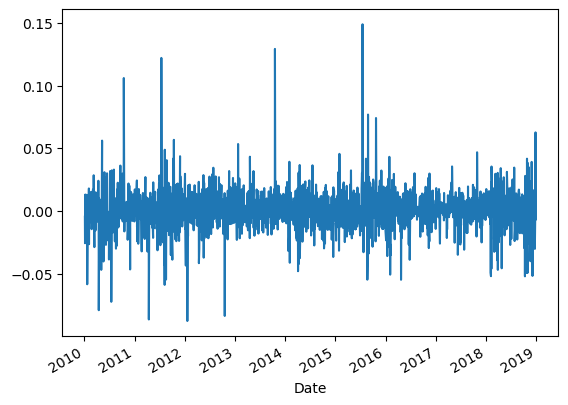

In [57]:
goog['LogRet'].plot()

In [58]:
''' looks pretty stationary, but it looks like variance does tend to increase in some places'''

' looks pretty stationary, but it looks like variance does tend to increase in some places'

In [59]:
adf(goog['LogPrice'])

Test-Statistics: -0.418190257890614
p-value: 0.9070170677498406
Non-Stationary


In [61]:
adf(goog['LogRet'].dropna())

Test-Statistics: -46.66748022773677
p-value: 0.0
stationary


In [62]:
adfuller(goog['LogRet'].dropna())

(np.float64(-46.66748022773677),
 0.0,
 0,
 2261,
 {'1%': np.float64(-3.4332455062745577),
  '5%': np.float64(-2.862819159865148),
  '10%': np.float64(-2.567450956377989)},
 np.float64(-12328.09150223395))

In [63]:
''' this looks pretty stationary'''

' this looks pretty stationary'

### looking at other stock starbucks

In [64]:
SBUX = stocks[stocks['Name']=='SBUX'][['Close']]
SBUX['LogPrice']=np.log(SBUX['Close'])
SBUX['LogRet'] = SBUX['LogPrice'].diff()

<Axes: xlabel='Date'>

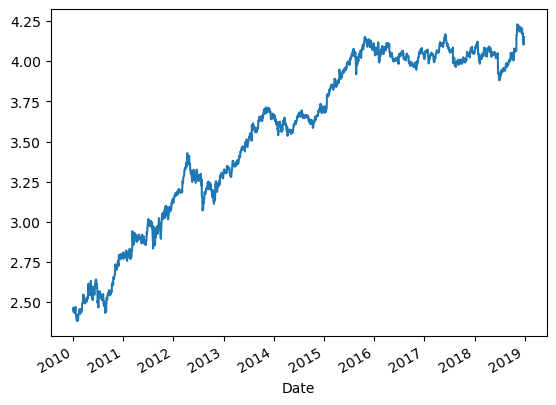

In [65]:
SBUX['LogPrice'].plot()

<Axes: xlabel='Date'>

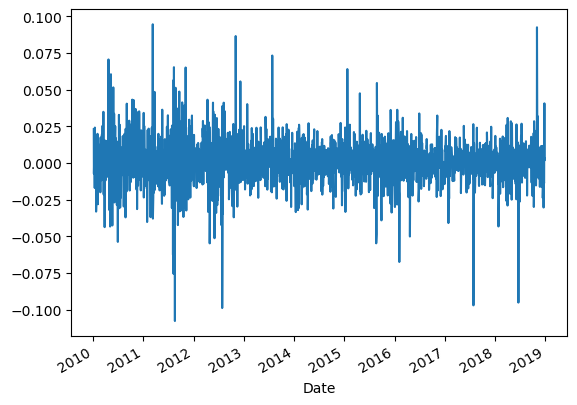

In [66]:
SBUX['LogRet'].plot()

In [68]:
adf(SBUX['LogPrice'])

Test-Statistics: -1.9020133583900003
p-value: 0.331114556985376
Non-Stationary


In [69]:
adf(SBUX['LogRet'].dropna())

Test-Statistics: -30.086501426958048
p-value: 0.0
stationary


In [70]:
adfuller(SBUX['LogRet'].dropna())

(np.float64(-30.086501426958048),
 0.0,
 2,
 2259,
 {'1%': np.float64(-3.433248072725654),
  '5%': np.float64(-2.8628202931061955),
  '10%': np.float64(-2.567451559747925)},
 np.float64(-12378.137938995795))

In [71]:
''' AGAIN THIS IS HIGHLY STATIONARY '''

' AGAIN THIS IS HIGHLY STATIONARY '

# conclusion - Log Returns are stationary